Connected to Python 3.13.5

In [ ]:
target_folders = [
    "Chinese law and policy",
    "Multinational",
    "NDAA provisionsUS federal lawsFY2026 NDAA", 
    "Corporate policies and commitments",
    "US federal laws",
    "US federal lawsNDAA provisionsFY2021 NDAA", 
    "US federal lawsNDAA provisionsFY2022 NDAA", 
    "US federal lawsNDAA provisionsFY2023 NDAA", 
    "US federal lawsNDAA provisionsFY2024 NDAA", 
    "US regulations executive orders and agency policies", 
    "US state and local documents"
]

# run the pipeline
communities, G, corpus, file_paths = map_folder_communities(target_folders, similarity_threshold=0.10)

from collections import defaultdict
groups = defaultdict(list)
for file, cid in communities.items():
    groups[cid].append(file)

for cid, files in groups.items():
    print(f"\n--- Community {cid} ---")
    print("\n".join(files))


plot_file_communities(G, communities, min_k_core=4, save_path="communities.png")

extract_community_topics(communities, corpus, file_paths, top_n=30)

NameError: name 'map_folder_communities' is not defined

In [ ]:
# imports
import matplotlib.pyplot as plt 
import random
import networkx as nx 
import string

from pathlib import Path
import nltk 
import re
import numpy as np
from collections import defaultdict
from nltk.corpus import stopwords
# from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import plotly.graph_objects as go
nltk.download("punkt", quiet=True)
nltk.download("stopwords", quiet=True)

True

In [ ]:
i

NameError: name 'i' is not defined

In [ ]:
# imports
import matplotlib.pyplot as plt 
import random
import networkx as nx 
import string

from pathlib import Path
import nltk 
import re
import numpy as np
from collections import defaultdict
from nltk.corpus import stopwords
# from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import plotly.graph_objects as go
nltk.download("punkt", quiet=True)
nltk.download("stopwords", quiet=True)

True

In [ ]:
def extract_community_topics(community_assignment, corpus, file_paths, top_n=5):
    """aggregates text by Louvain community and extracts the most distinctive keywords
    using TF-IDF.
    """
    #  txt data by community ids 
    community_texts = {}
    for text, file_name in zip(corpus, file_paths):
        # find which community this file belongs to
        comm_id = community_assignment.get(file_name)

        if comm_id is not None:
            if comm_id not in community_texts:
                community_texts[comm_id] = []
            community_texts[comm_id].append(text)

    # combine all into a block 
    ordered_communities = sorted(list(community_texts.keys()))
    combined_corpus = [
        " ".join(community_texts[cid]) for cid in ordered_communities
    ]

    # find unique clusters 
    custom_stops = (
        list(TfidfVectorizer(stop_words="english").get_stop_words())
        + ["section", "shall", "use", "b", "c"]
    )
    vectorizer = TfidfVectorizer(
        stop_words=custom_stops, token_pattern=r"(?u)\b[a-zA-Z]{3,}\b"
    )

    tfidf_matrix = vectorizer.fit_transform(combined_corpus)
    feature_names = np.array(vectorizer.get_feature_names_out())

    # print defining terms
    print("community determinants")
    for idx, comm_id in enumerate(ordered_communities):
  
        row = tfidf_matrix.getrow(idx).toarray()[0]

 
        top_indices = np.argsort(row)[::-1][:top_n]
        top_keywords = feature_names[top_indices]


        file_count = len(community_texts[comm_id])

        print(f"community {comm_id} ({file_count} files)")
        print(f"top keywords: {', '.join(top_keywords)}")

In [ ]:
def map_folder_communities(dir_paths_list, similarity_threshold = 0.25): 
    """
    loads txt files, calculate similarity between them, and identifies file communities using the louvain algorithim
    """
    file_paths = []
    corpus = []

    random.seed(42)


    for dir_path in dir_paths_list:
        folder = Path(dir_path)
        if not folder.exists():
            print(f"directory not found: {folder}")
            continue
            
        print(f"reading files from: {folder.resolve()}")

    # read .txt files 
    for file_path in folder.rglob('*.txt'): 
        try:
            content = file_path.read_text()
            if content.strip():
                corpus.append(content)
                # file_paths.append(file_path.name) # store filename as node
                match = re.search(r"\d+", file_path.name)
                if match:
                    file_number = match.group()
                else:
                    file_number = file_path.stem

                file_paths.append(file_number)
                
        except Exception as e: 
            print(f"skipping file {file_path.name} : {e}")
    if not corpus: 
        print(' no valid .txt files found')
        return {}, nx.Graph()
        
        # vectorize text and compare pairwaire similarity 

    custom_stops = list(TfidfVectorizer(stop_words='english').get_stop_words()) + ['section', 'shall', 'use', 'b', ' c']
    vectorizer = TfidfVectorizer(stop_words='english',token_pattern=r'(?u)\b[a-zA-Z]{3,}\b',max_df=0.85,min_df=1)

    tfidf_matrix = vectorizer.fit_transform(corpus)
    similarity_matrix = cosine_similarity(tfidf_matrix)


        # network graph 

    G = nx.Graph()
    num_files = len(file_paths)

    for i in range(num_files): 
        G.add_node(file_paths[i])
        for j in range(i + 1, num_files): 
            weight = similarity_matrix[i, j]

                # similarity threshold
            if weight > similarity_threshold:
                G.add_edge(file_paths[i], file_paths[j], weight = weight)

        # lovain algo — returns {filename: community_id}
    communities = nx.community.louvain_communities(G, weight = 'weight', resolution=2.5)
    community_assignment = {}
    for community_id, node_set in enumerate(communities):
        for node in node_set:
            community_assignment[node] = community_id

    community_assignment = {}
    for community_id, node_set in enumerate(communities): 
        for node in node_set:
            community_assignment[node] = community_id
    print(f"processed {len(file_paths)} files into {len(communities)} distinct communities.")
    return community_assignment, G, corpus, file_paths

In [ ]:
def plot_file_communities(
    G,
    community_assignment,
    min_k_core=10,
    save_path="file_network.png",
    community_legend_mapping=None,
):
    """filters and plots network graph with localized community sizes and labels."""
    if G.number_of_nodes() == 0:
        print("the graph is empty. Nothing to plot.")
        return
    if community_legend_mapping is None:
        community_legend_mapping = {
            0: "Healthcare",
            1: "Chatbots",
            2: "Oversight",
            3: "Government - Other",
            4: "Privacy",
            5: "Employment",
            6: "Models",
            7: "Commissions",
            8: "Biometrics",
            9: "Risk",
            10:"Elections",
            11: "Hiring",
            12: "Consumer Protection",
            13: "Government - State and local",
            14: "Vehicles",
            15: "Education - Higher ED",
            16: "Education",
            17: "Legal",
            18: "Tax",
            19: "Welfare",
            20: "Government -Federal", # dropped 
            21: "Misc.", # dropped 
            22: "Defense", # dropped
            23: "Aviation", # dropped 
        }

    if community_legend_mapping is None:
        community_legend_mapping = {}

    plt.figure(figsize=(12, 12))

    # reduce graph density
    try:
        G_filtered = nx.k_core(G, k=min_k_core)
    except nx.NetworkXError:
        G_filtered = G
        print(f"graph too small for k-core={min_k_core}, plotting full graph.")

    # spring layput
    pos = nx.spring_layout(G_filtered, k=0.5, iterations=50, seed=42)

    filtered_communities = set(
        community_assignment.get(node, -1) for node in G_filtered.nodes()
    )
    unique_communities = sorted(list(filtered_communities))
    cmap = plt.cm.get_cmap("tab20", max(len(unique_communities), 1))
    num_communities = max(len(unique_communities), 1)

    # map node size correlated with degree
    degrees = dict(G_filtered.degree())

    for i, community_id in enumerate(unique_communities):
        # filter nodes in the loop
        node_list = [
            node
            for node in G_filtered.nodes()
            if community_assignment.get(node, -1) == community_id
            and node in pos
        ]
        if not node_list:
            continue

        # calculate sizes ONLY for the nodes in the current node_list
        node_sizes = [degrees[node] * 10 for node in node_list]
        color = cmap(i / num_communities)

        # Resolve legend labels
        if community_id in community_legend_mapping:
            label_text = community_legend_mapping[community_id]
        elif community_id == -1:
            label_text = "Unassigned"
        else:
            label_text = f"Community {community_id} (Unknown)"

        # draw netowrk nodes
        nx.draw_networkx_nodes(
            G_filtered,
            pos,
            node_size=node_sizes,
            nodelist=node_list,
            node_color=[color] * len(node_list),
            alpha=0.85,
            label=label_text,  
        )

    # edges and labels 
    nx.draw_networkx_edges(G_filtered, pos, alpha=0.08, edge_color="gray")
    nx.draw_networkx_labels(G_filtered, pos, font_size=5)

    # legend placement 
    plt.legend(
        scatterpoints=1,
        markerscale=.5,
        loc="upper left",
        bbox_to_anchor=(
            1.02,
            1,
        ),  
        borderaxespad=0, 
        fontsize=10,  
        labelspacing=0.4, 
    )

    plt.title(
        f"AGORA Network Mapping (Filtered Layout: {G_filtered.number_of_nodes()} Nodes)",
        fontsize=14,
    )
    plt.axis("off")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

reading files from: /Users/rhea/Desktop/network_analytics/agora/Chinese law and policy
reading files from: /Users/rhea/Desktop/network_analytics/agora/Multinational
reading files from: /Users/rhea/Desktop/network_analytics/agora/NDAA provisionsUS federal lawsFY2026 NDAA
reading files from: /Users/rhea/Desktop/network_analytics/agora/Corporate policies and commitments
reading files from: /Users/rhea/Desktop/network_analytics/agora/US federal laws
reading files from: /Users/rhea/Desktop/network_analytics/agora/US federal lawsNDAA provisionsFY2021 NDAA
reading files from: /Users/rhea/Desktop/network_analytics/agora/US federal lawsNDAA provisionsFY2022 NDAA
reading files from: /Users/rhea/Desktop/network_analytics/agora/US federal lawsNDAA provisionsFY2023 NDAA
reading files from: /Users/rhea/Desktop/network_analytics/agora/US federal lawsNDAA provisionsFY2024 NDAA
reading files from: /Users/rhea/Desktop/network_analytics/agora/US regulations executive orders and agency policies
reading fi

<ipython-input-7-62b071cf54c2>:59: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", max(len(unique_communities), 1))


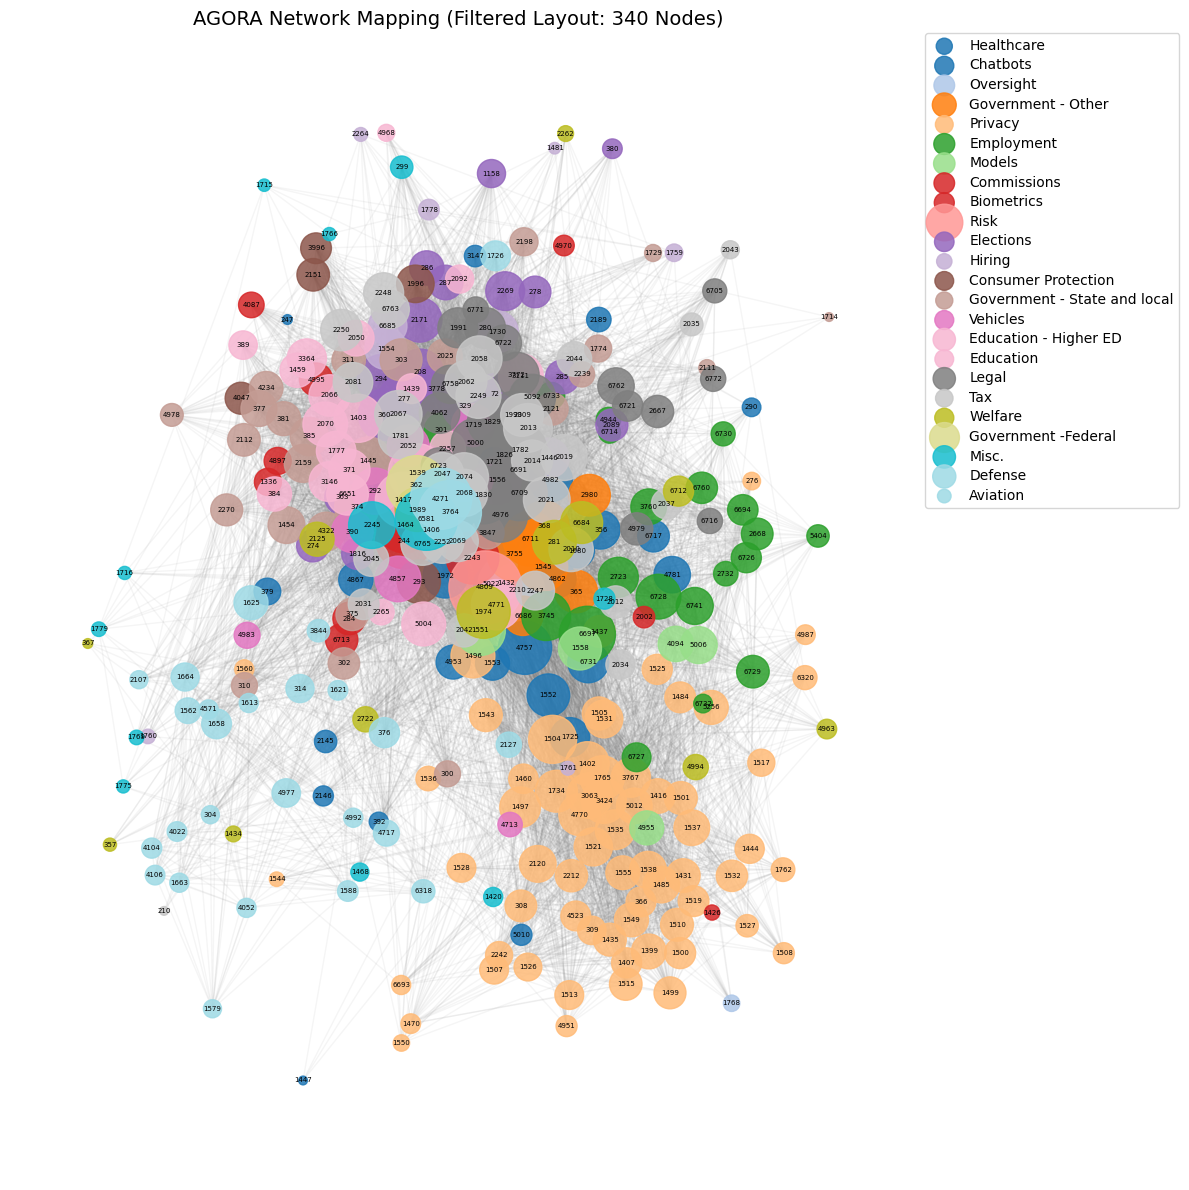

community determinants
community 0 (23 files)
top keywords: health, care, patient, insurer, services, medical, provider, plan, enrollee, clinical, mental, licensed, utilization, review, artificial, intelligence, act, lenses, code, information, eye, physician, providers, retrospectively, nursing, chapter, necessity, prescription, means, concurrent
community 1 (4 files)
top keywords: occupation, artificial, intelligence, division, generative, violation, person, chapter, consumer, utah, state, regulated, individual, means, effective, court, interaction, noncertified, services, human, interacting, personhood, violative, act, advice, annotated, protection, enacted, law, provision
community 2 (3 files)
top keywords: chapter, state, systems, appears, agencies, excepted, department, effective, implemented, recommendation, date, following, procedures, information, technology, newly, relative, decision, human, compliance, circumstances, provisions, prohibited, person, agency, rsa, iii, used, rem

In [ ]:
target_folders = [
    "Chinese law and policy",
    "Multinational",
    "NDAA provisionsUS federal lawsFY2026 NDAA", 
    "Corporate policies and commitments",
    "US federal laws",
    "US federal lawsNDAA provisionsFY2021 NDAA", 
    "US federal lawsNDAA provisionsFY2022 NDAA", 
    "US federal lawsNDAA provisionsFY2023 NDAA", 
    "US federal lawsNDAA provisionsFY2024 NDAA", 
    "US regulations executive orders and agency policies", 
    "US state and local documents"
]

# run the pipeline
communities, G, corpus, file_paths = map_folder_communities(target_folders, similarity_threshold=0.10)

from collections import defaultdict
groups = defaultdict(list)
for file, cid in communities.items():
    groups[cid].append(file)

for cid, files in groups.items():
    print(f"\n--- Community {cid} ---")
    print("\n".join(files))


plot_file_communities(G, communities, min_k_core=4, save_path="communities.png")

extract_community_topics(communities, corpus, file_paths, top_n=30)

reading files from: /Users/rhea/Desktop/network_analytics/agora/Chinese law and policy
reading files from: /Users/rhea/Desktop/network_analytics/agora/Multinational
reading files from: /Users/rhea/Desktop/network_analytics/agora/US federal laws
reading files from: /Users/rhea/Desktop/network_analytics/agora/US regulations executive orders and agency policies
processed 37 files into 19 distinct communities.

--- Community 0 ---
1322

--- Community 1 ---
1955
181
1018

--- Community 2 ---
177

--- Community 3 ---
176

--- Community 4 ---
73

--- Community 5 ---
173

--- Community 6 ---
169

--- Community 7 ---
183
182

--- Community 8 ---
178
170
174

--- Community 9 ---
179
180

--- Community 10 ---
2273
1187

--- Community 11 ---
1806
2267
1112
1034
1026
1033
1036
1027
2268

--- Community 12 ---
1111
2546
1780

--- Community 13 ---
1025

--- Community 14 ---
175
1029

--- Community 15 ---
1021

--- Community 16 ---
168

--- Community 17 ---
1188

--- Community 18 ---
1189


<ipython-input-7-62b071cf54c2>:59: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", max(len(unique_communities), 1))


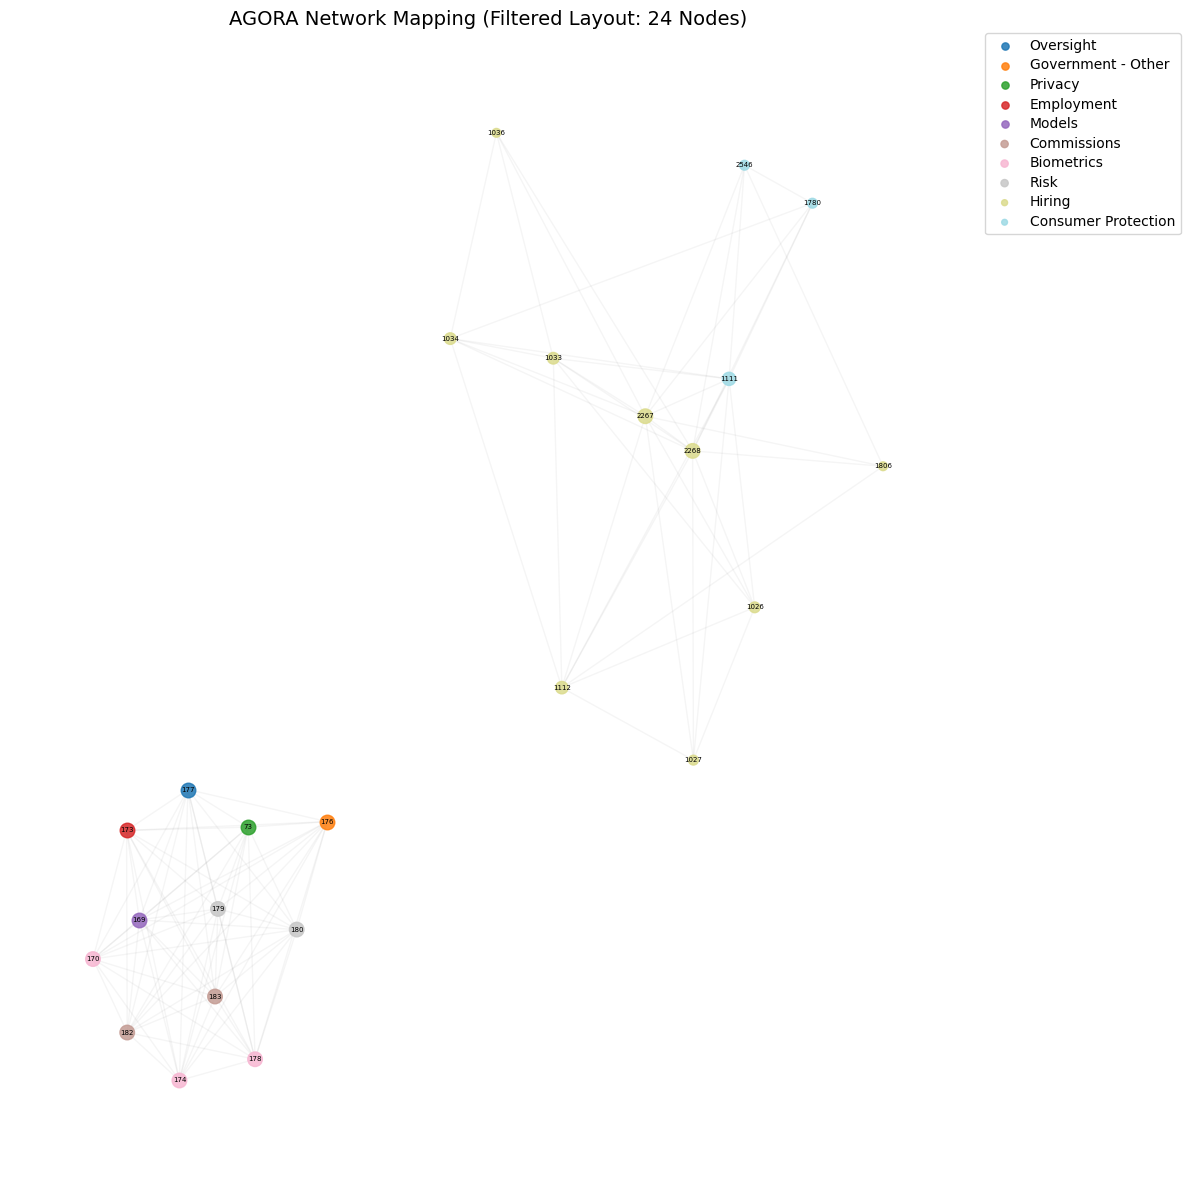

community determinants
community 0 (1 files)
top keywords: commission, political, candidate, acting, employee, agent, behalf, fraudulently, speaking, thereof, statute, writing, misrepresent, party, technology, does, media, donations, campaign, barring, ing, election, misrepresentation, act, participating, willfully, soliciting, conspiring, developments, knowingly
community 1 (3 files)
top keywords: iaas, icts, transaction, foreign, secretary, provider, determination, person, reseller, cip, information, paragraph, products, cyber, account, department, malicious, means, enabled, customer, security, united, initial, covered, states, jurisdiction, model, including, adversary, written
community 2 (1 files)
top keywords: acoustic, device, heart, coronary, artery, disease, testing, fully, justification, sounds, described, indicator, signals, performance, patient, placement, sensor, factors, risk, algorithm, population, instructions, fulfill, using, data, acquisition, following, include, bandw

In [ ]:
target_folders = [
    "Chinese law and policy",
    "Multinational",
    # "NDAA provisionsUS federal lawsFY2026 NDAA", 
    # "Corporate policies and commitments",
    "US federal laws",
    # "US federal lawsNDAA provisionsFY2021 NDAA", 
    # "US federal lawsNDAA provisionsFY2022 NDAA", 
    # "US federal lawsNDAA provisionsFY2023 NDAA", 
    # "US federal lawsNDAA provisionsFY2024 NDAA", 
    "US regulations executive orders and agency policies", 
    # "US state and local documents"
]

# run the pipeline
communities, G, corpus, file_paths = map_folder_communities(target_folders, similarity_threshold=0.15)

from collections import defaultdict
groups = defaultdict(list)
for file, cid in communities.items():
    groups[cid].append(file)

for cid, files in groups.items():
    print(f"\n--- Community {cid} ---")
    print("\n".join(files))


plot_file_communities(G, communities, min_k_core=4, save_path="communities.png")

extract_community_topics(communities, corpus, file_paths, top_n=30)